# Final Project: Student Performance Analysis

## Student: Guillermo Jurado

This notebook explores the `Student_performance_data.csv` dataset and investigates the following project questions:

- Which feature has the biggest impact on `GradeClass`?
- Which feature has the least impact on `GradeClass`?
- Does participating in `Music` appear to help more than `Sports`?

The main features of interest are:

- `ParentalEducation`
- `StudyTimeWeekly`
- `Absences`
- `Tutoring`
- `Music`
- `Sports`


## 1. Imports

If a package import fails, install it in your notebook environment first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load the Dataset

In [2]:
df = pd.read_csv("Student_performance_data.csv")
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [3]:
print("Rows, columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Rows, columns: (2392, 15)

Columns:
['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']


## 3. Basic Data Inspection

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [5]:
missing_values = df.isnull().sum()
missing_values

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

## 4. Summary Statistics for Features of Interest

In [6]:
features_of_interest = [
    "ParentalEducation",
    "StudyTimeWeekly",
    "Absences",
    "Tutoring",
    "Music",
    "Sports",
    "GradeClass"
]

summary_table = pd.DataFrame({
    "mean": df[features_of_interest].mean(),
    "median": df[features_of_interest].median(),
    "mode": df[features_of_interest].mode().iloc[0],
    "variance": df[features_of_interest].var(),
    "std_dev": df[features_of_interest].std()
})

summary_table

,mean,median,mode,variance,std_dev
ParentalEducation,1.746237,2.000000,2.000000,1.000822,1.000411
StudyTimeWeekly,9.771992,9.705363,0.001057,31.953857,5.652774
Absences,14.541388,15.000000,13.000000,71.697157,8.467417
Tutoring,0.301421,0.000000,0.000000,0.210655,0.458971
Music,0.196906,0.000000,0.000000,0.158200,0.397744
Sports,0.303512,0.000000,0.000000,0.211481,0.459870
GradeClass,2.983696,4.000000,4.000000,1.522528,1.233908


## 5. Distributions

These plots show how the main variables are distributed and give a quick picture of what the dataset looks like before modeling.

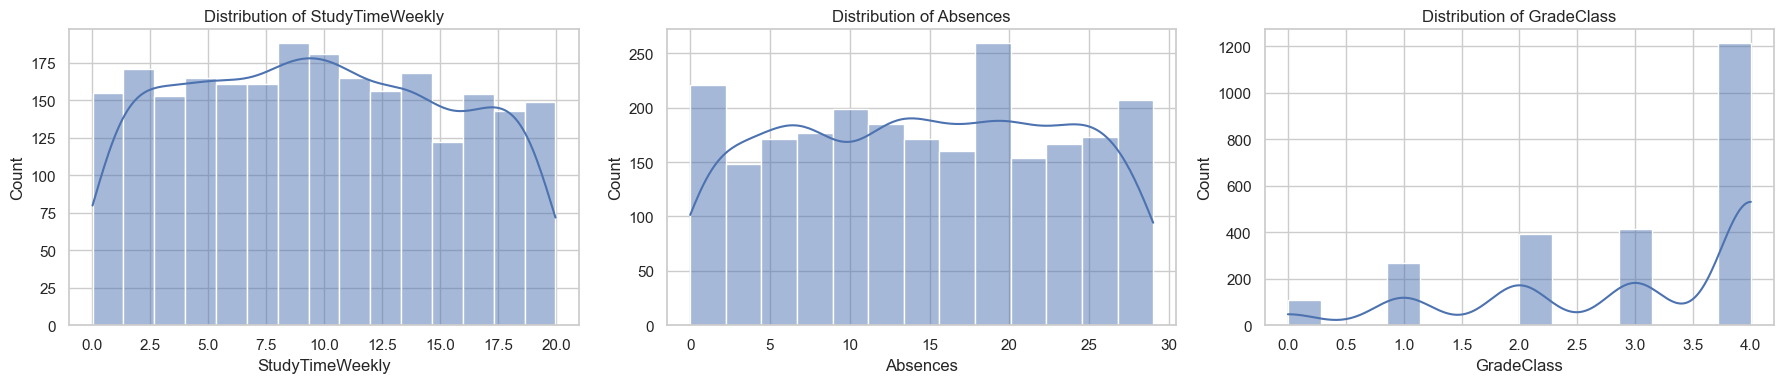

In [7]:
plot_columns = ["StudyTimeWeekly", "Absences", "GradeClass"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, column in zip(axes, plot_columns):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()

## 6. Correlation Analysis

This checks which selected features have the strongest relationship with `GradeClass`.

Based on the current results from this dataset, `Absences` has the strongest relationship with `GradeClass` by a wide margin. The other features have much weaker relationships, although `StudyTimeWeekly` and `Tutoring` still show a small helpful trend.

In [8]:
correlations = df[features_of_interest].corr(numeric_only=True)["GradeClass"].sort_values(key=abs, ascending=False)
correlations

GradeClass           1.000000
Absences             0.728633
StudyTimeWeekly     -0.134131
Tutoring            -0.111695
ParentalEducation    0.041031
Music               -0.036065
Sports              -0.026654
Name: GradeClass, dtype: float64

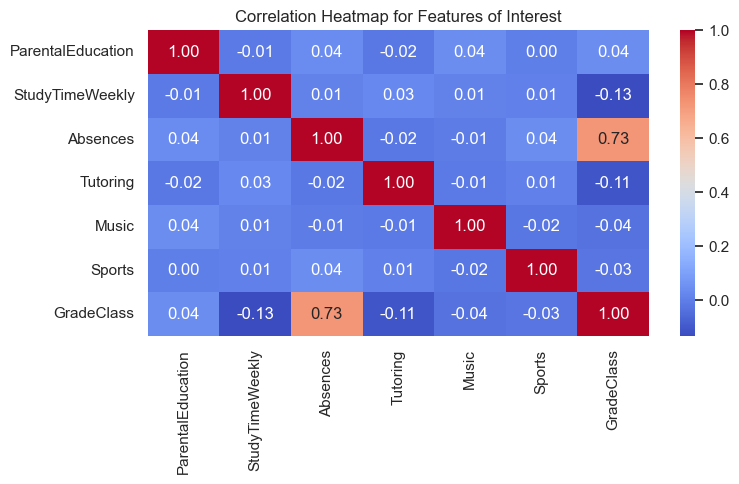

In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[features_of_interest].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap for Features of Interest")
plt.tight_layout()

## 7. Music vs Sports

This section compares average `GradeClass` for students involved in music and sports.

In this dataset, lower `GradeClass` values correspond to better outcomes. That means a lower average in this section suggests slightly stronger performance.

In [10]:
music_comparison = df.groupby("Music")["GradeClass"].mean()
sports_comparison = df.groupby("Sports")["GradeClass"].mean()

print("Average GradeClass by Music participation:")
display(music_comparison)

print("Average GradeClass by Sports participation:")
display(sports_comparison)

Average GradeClass by Music participation:


Music
0    3.005726
1    2.893843
Name: GradeClass, dtype: float64

Average GradeClass by Sports participation:


Sports
0    3.005402
1    2.933884
Name: GradeClass, dtype: float64

In [11]:
comparison_df = pd.DataFrame({
    "Music": df.groupby("Music")["GradeClass"].mean(),
    "Sports": df.groupby("Sports")["GradeClass"].mean()
})
comparison_df

,Music,Sports
0,3.005726,3.005402
1,2.893843,2.933884


## 8. Linear Regression Model

A linear regression model is used here because the proposal identified it as the starting model for predicting `GradeClass`.

The goal here is not just prediction, but also interpretation. By looking at the model coefficients, we can estimate which variables seem to have the most influence on student grade classification.

In [12]:
model_features = [
    "ParentalEducation",
    "StudyTimeWeekly",
    "Absences",
    "Tutoring",
    "Music",
    "Sports"
]

X = df[model_features]
y = df["GradeClass"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)
rounded_pred = np.clip(np.rint(y_pred), 0, 4)


In [13]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
rounded_accuracy = (rounded_pred == y_test).mean()

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")
print(f"Rounded class accuracy: {rounded_accuracy:.4%}")

MAE: 0.5852
RMSE: 0.7927
R^2: 0.5794
Rounded class accuracy: 56.3674%


In [14]:
importance_df = pd.DataFrame({
    "Feature": model_features,
    "Coefficient": linear_model.coef_
})

importance_df["AbsoluteCoefficient"] = importance_df["Coefficient"].abs()
importance_df = importance_df.sort_values("AbsoluteCoefficient", ascending=False)
importance_df

,Feature,Coefficient,AbsoluteCoefficient
3,Tutoring,-0.280075,0.280075
5,Sports,-0.128723,0.128723
2,Absences,0.105725,0.105725
4,Music,-0.102890,0.102890
1,StudyTimeWeekly,-0.028260,0.028260
0,ParentalEducation,0.019737,0.019737


C:\Users\gjura\AppData\Local\Temp\ipykernel_22000\725737242.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Coefficient", y="Feature", palette="viridis")


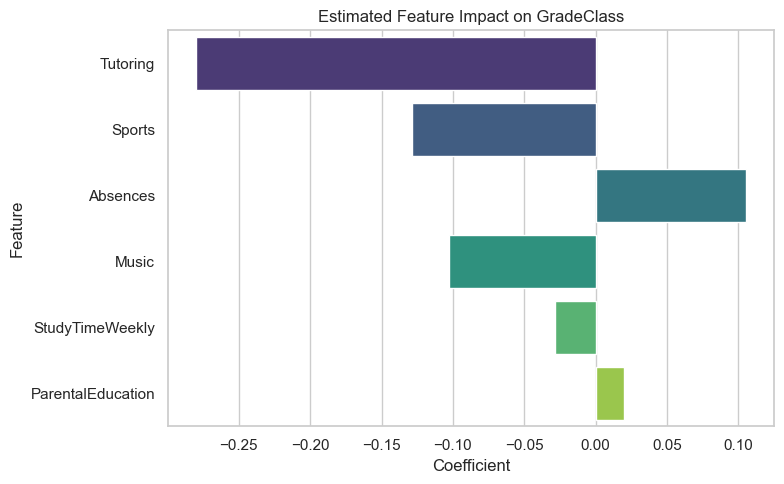

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Coefficient", y="Feature", palette="viridis")
plt.title("Estimated Feature Impact on GradeClass")
plt.tight_layout()

## 9. Written Takeaways

This section summarizes the main findings from the exploratory analysis and the linear regression model.

- The strongest predictor in this linear regression model appears to be `Tutoring`, because it has the largest regression coefficient by magnitude. `Absences` still stands out as an important variable because it has the strongest positive relationship with worse grade classifications in the correlation analysis.
- The weakest predictor appears to be `ParentalEducation`, which had only a very small relationship with `GradeClass` in this model.
- `Music` seems to have a slightly stronger helpful effect than `Sports`, but both effects are still smaller than the effect of `Tutoring` in this model.
- `StudyTimeWeekly` and `Tutoring` both appear to be associated with better outcomes because they push predicted `GradeClass` downward.
- One limitation of this model is that linear regression may not capture more complex relationships in student performance, especially since `GradeClass` is really a small set of categories from 0 to 4 instead of a truly continuous variable.
- Another limitation is that correlation does not prove causation. For example, music participation may be associated with better performance without directly causing it.

Conclusion:

Overall, this project suggests that tutoring has the strongest effect in the linear regression model out of the variables I selected, while absences remain one of the clearest warning signs of worse grade classifications. Students with more absences tend to receive worse grade classifications, while tutoring, more weekly study time, and music participation are linked to better results. Music also appears to have a slightly more positive association than sports in this dataset, although the difference is not large. The model was useful for identifying patterns, but it should be interpreted carefully because it simplifies a more complicated picture of student performance.


## 10. Presentation Notes

A few short speaking points you can use for class:

- I chose this dataset because I was especially interested in whether music participation might connect to student performance.
- My main question was which factors most strongly affect `GradeClass`.
- The clearest result was that absences mattered the most.
- Study time and tutoring also seemed helpful.
- Music had a slightly better relationship with performance than sports, but neither was as important as absences.
- A major limitation is that this model shows patterns and relationships, not proof of cause and effect.
